In [1]:
import os
import h5py
import pandas as pd
from tqdm import tqdm
import numpy as np

In [2]:
import torch
import torchaudio
import random
from biodenoising import pretrained
from biodenoising.denoiser.dsp import convert_audio
import matplotlib.pyplot as plt
from torchaudio.transforms import MelSpectrogram, AmplitudeToDB

In [3]:
from IPython import display as disp

In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [5]:
model = pretrained.biodenoising16k_dns48().to(device)

In [6]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [7]:
# dataset_name = 'primary_matches'
# dataset_folder = f'processed_data/filtered_pairs/{dataset_name}'

original_df = pd.read_csv('processed_data/expanded_df_formatted.csv')
h5_path = 'processed_data/expanded_spectrograms.h5'

In [8]:
class CFG:
    LOAD_DATA = True
    FS = 16000 # 16kHz
    TARGET_DURATION = 5.0
    TARGET_SHAPE = (256, 256)
    
    N_FFT = 1024
    HOP_LENGTH = 512
    N_MELS = 128
    FMIN = 50
    FMAX = 14000
    POWER = 2

cfg = CFG()

In [9]:
def spectrogram_to_audio(spectrogram, n_fft=1024, hop_length=512):
    """Convert magnitude spectrogram back to audio using Griffin-Lim."""
    spectrogram_tensor = torch.from_numpy(spectrogram).float().to(device)
    audio = torchaudio.transforms.GriffinLim(
        n_fft=n_fft,
        hop_length=hop_length,
    )(spectrogram_tensor)
    return audio

In [10]:
mel_spec = MelSpectrogram(
    sample_rate=model.sample_rate,
    n_fft=1024,
    hop_length=512,
    n_mels=128
).to(device)
db_transform = AmplitudeToDB().to(device)

In [12]:
def show_melspectrogram(audio_tensor, title):
    spec = mel_spec(audio_tensor)
    spec_db = db_transform(spec)
    plt.figure(figsize=(10, 4))
    plt.imshow(spec_db[0].cpu(), origin='lower', aspect='auto', cmap='viridis')
    plt.title(title)
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

 36%|███████████████████████████████████████████████▎                                                                                    | 41342/115357 [00:00<00:00, 104829.12it/s]

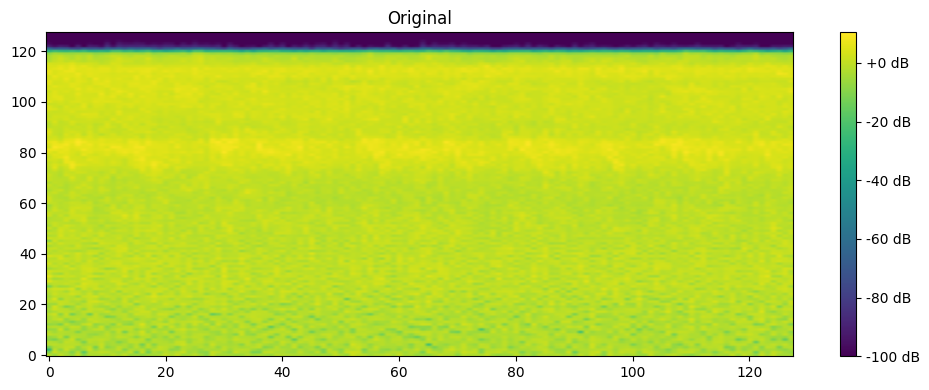

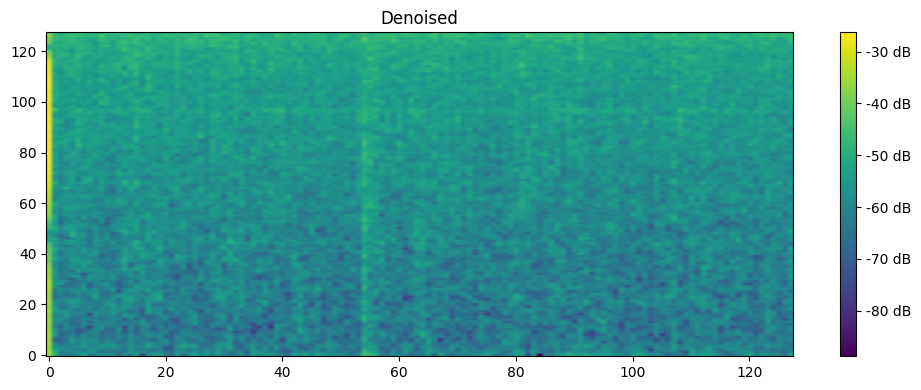

 43%|█████████████████████████████████████████████████████████▋                                                                           | 50000/115357 [00:01<00:02, 28584.57it/s]


In [15]:
with h5py.File(h5_path, 'r') as src_h5:
    src_dset = src_h5['spectrograms']
    
    griffin_lim = torchaudio.transforms.GriffinLim(
        n_fft=510,  # 256 freq bins → n_fft = 2*(256-1)
        hop_length=256,  # Typical: n_fft//2
        win_length=510,
        power=1.0,
        n_iter=32
    ).to(device)
    
    for idx, row in tqdm(original_df.iterrows(), total=len(original_df)):

        if idx == 0 or idx % 50000 != 0:
            continue

        spec = src_dset[idx]
        
        if spec.shape[0] != 256: # ensure proper shape
            spec = spec.T
            
        spec_tensor = torch.from_numpy(spec).float().to(device)
        
        try:
            audio = griffin_lim(spec_tensor)
            audio = audio.unsqueeze(0)
            
            audio_resampled = torchaudio.functional.resample(
                audio,
                orig_freq=16000,
                new_freq=model.sample_rate
            )
            
            audio_resampled = audio_resampled / torch.max(torch.abs(audio_resampled))
            
            with torch.no_grad():
                denoised = model(audio_resampled.unsqueeze(0))[0]

            show_melspectrogram(audio, 'Original')
            show_melspectrogram(denoised, 'Denoised')

            # disp.display(disp.Audio(audio.data.cpu().numpy(), rate=model.sample_rate))
            # disp.display(disp.Audio(denoised.data.cpu().numpy(), rate=model.sample_rate))
            
        except Exception as e:
            print(f"Skipping index {idx}: {str(e)}")
            continue

        break

I don't trust the 10 second snipppets, so I'm going to try again, but with biodenoising. Or preferably, use biodenoising first to filter out the sections I need to get.

In [19]:
original_train_df = pd.read_csv('dataset/train.csv')
original_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28564 entries, 0 to 28563
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     28564 non-null  object 
 1   secondary_labels  28564 non-null  object 
 2   type              28564 non-null  object 
 3   filename          28564 non-null  object 
 4   collection        28564 non-null  object 
 5   rating            28564 non-null  float64
 6   url               28564 non-null  object 
 7   latitude          27755 non-null  float64
 8   longitude         27755 non-null  float64
 9   scientific_name   28564 non-null  object 
 10  common_name       28564 non-null  object 
 11  author            28564 non-null  object 
 12  license           28564 non-null  object 
dtypes: float64(3), object(10)
memory usage: 2.8+ MB


 49%|█████████████████████████████████████████████████████████████████▎                                                                    | 13912/28564 [00:00<00:00, 70276.17it/s]

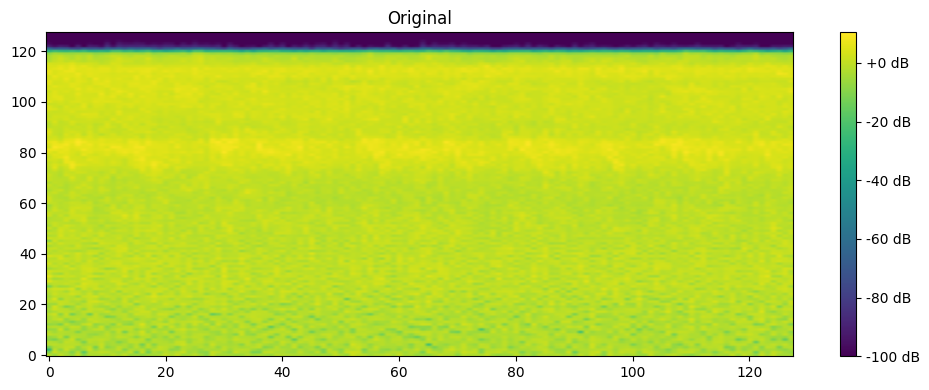

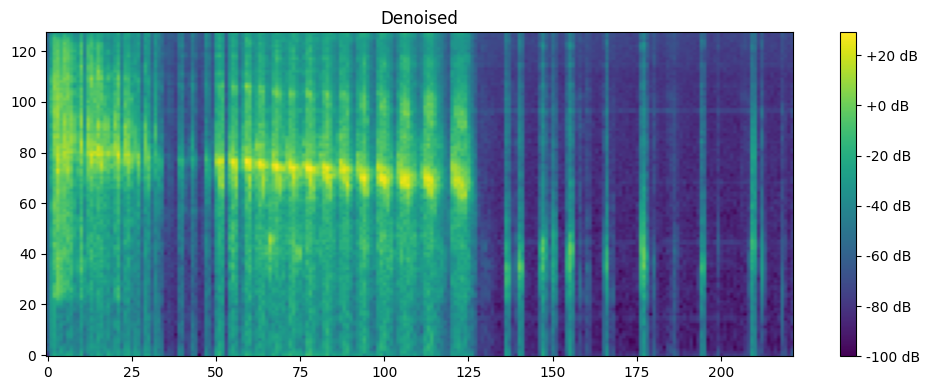

 53%|██████████████████████████████████████████████████████████████████████▎                                                               | 15000/28564 [00:01<00:01, 10228.11it/s]


In [ ]:
for idx, row in tqdm(original_train_df.iterrows(), total=len(original_train_df)):
    if idx == 0 or idx % 15000 != 0:
        continue
    
    wav, sr = torchaudio.load(os.path.join('dataset/train_audio', row['filename']))
    wav = convert_audio(wav, sr, model.sample_rate, model.chin).to(device)
    with torch.no_grad():
        denoised = model(wav.unsqueeze(0))[0]
        
    show_melspectrogram(audio, 'Original')
    show_melspectrogram(denoised, 'Denoised')

    break

In [30]:
def detect_active_regions(audio, sample_rate, threshold_db=-40, min_silence_dur=0.1):
    """
    Returns list of (start_sample, end_sample) tuples for non-silent regions
    """
    # Convert to mono if needed and ensure it's a tensor
    if isinstance(audio, np.ndarray):
        audio = torch.from_numpy(audio)
    if audio.ndim > 1:
        audio = audio.mean(dim=0)
    
    # Parameters
    frame_length = int(0.01 * sample_rate)  # 10ms frames
    hop_length = frame_length // 2
    
    # Calculate RMS energy manually
    rms = []
    for i in range(0, len(audio) - frame_length + 1, hop_length):
        frame = audio[i:i + frame_length]
        rms.append(torch.sqrt(torch.mean(frame ** 2)))
    rms = torch.tensor(rms)
    
    # Convert to dB scale
    max_rms = torch.max(rms) + 1e-10  # Avoid division by zero
    rms_db = 20 * torch.log10(rms / max_rms)
    
    # Find active regions
    active = rms_db > threshold_db
    active_regions = []
    current_start = None
    
    for i, is_active in enumerate(active):
        sample_pos = i * hop_length
        if is_active and current_start is None:
            current_start = sample_pos
        elif not is_active and current_start is not None:
            duration = (sample_pos - current_start) / sample_rate
            if duration >= min_silence_dur:
                active_regions.append((current_start, sample_pos))
            current_start = None
    
    # Add last region if active until end
    if current_start is not None:
        active_regions.append((current_start, len(audio)))
    
    return active_regions

In [ ]:
def extract_10s_segments(audio, sample_rate, active_regions):
    segments = []
    target_length = 10 * sample_rate
    
    for start, end in active_regions:
        region_length = end - start
        
        # If region is longer than 10s, split it
        if region_length >= target_length:
            num_segments = region_length // target_length
            for i in range(num_segments):
                seg_start = start + i * target_length
                seg_end = seg_start + target_length
                segments.append(audio[seg_start:seg_end])
        
        # Else keep as is (shorter than 10s)
        else:
            segments.append(audio[start:end])
    
    return segments

In [32]:
def visualize_active_regions(audio, sample_rate, active_regions, title="Active Regions"):
    """
    Visualizes audio waveform with red boxes around active (non-silent) regions
    
    Args:
        audio: Tensor or numpy array (1D)
        sample_rate: Audio sample rate
        active_regions: List of (start_sample, end_sample) tuples
        title: Plot title
    """
    # Convert to numpy if needed
    if isinstance(audio, torch.Tensor):
        audio = audio.cpu().numpy()
    
    # Create time axis
    duration = len(audio) / sample_rate
    time = np.linspace(0, duration, len(audio))
    
    # Plot waveform
    plt.figure(figsize=(15, 4))
    plt.plot(time, audio, alpha=0.6)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    
    # Highlight active regions
    for start, end in active_regions:
        start_time = start / sample_rate
        end_time = end / sample_rate
        plt.axvspan(start_time, end_time, color='red', alpha=0.3)
    
    # Add legend
    plt.legend(["Waveform", "Active Regions"], loc='upper right')
    
    plt.tight_layout()
    plt.show()

  0%|                                                                                                                                                     | 0/28564 [00:00<?, ?it/s]

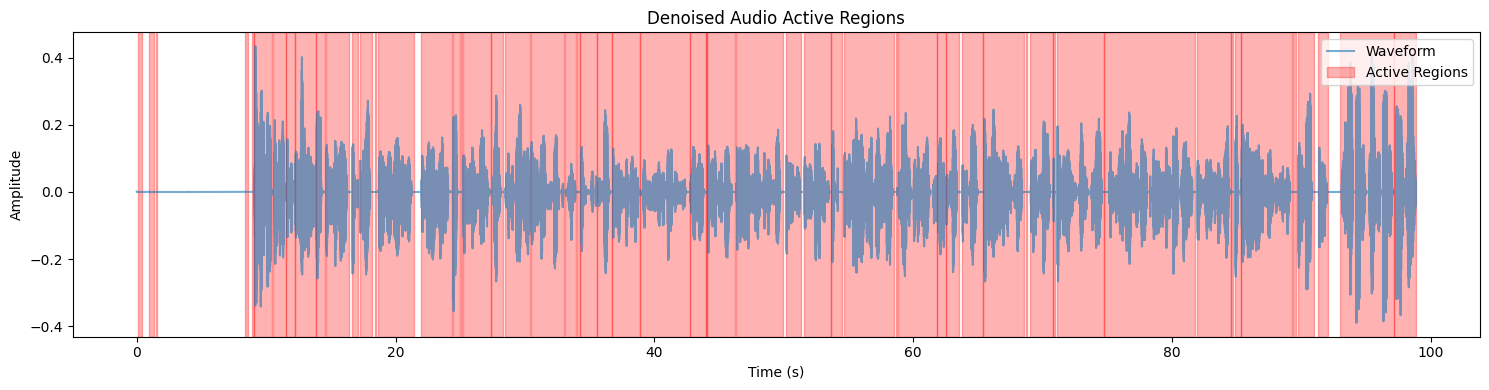

  0%|                                                                                                                                                     | 0/28564 [00:02<?, ?it/s]

[(1280, 6800), (15440, 21920), (23760, 25520), (134000, 137360), (142320, 144480), (145520, 167600), (168960, 184640), (184960, 195920), (196000, 221440), (221680, 232640), (234000, 262480), (265760, 274080), (275440, 290800), (294160, 296000), (298720, 342560), (351600, 389440), (390560, 399120), (400320, 402080), (403040, 437920), (438000, 452240), (455520, 485840), (487440, 528560), (528880, 543520), (544880, 547840), (548480, 568880), (569120, 587760), (587920, 621600), (622400, 683600), (684080, 703520), (703600, 705440), (705600, 740240), (740640, 799520), (802160, 821120), (824960, 857920), (858080, 872080), (873840, 936560), (938240, 940480), (941680, 989760), (989840, 1000480), (1000560, 1016800), (1020000, 1046000), (1046480, 1096640), (1099040, 1100800), (1104800, 1132320), (1132400, 1135280), (1137440, 1195360), (1196080, 1308960), (1310560, 1353040), (1353120, 1355920), (1357680, 1365040), (1365600, 1427840), (1429440, 1433680), (1435280, 1455280), (1460800, 1472880), (148

In [37]:
for idx, row in tqdm(original_train_df.iterrows(), total=len(original_train_df)):
    # Load and denoise
    wav, sr = torchaudio.load(os.path.join('dataset/train_audio', row['filename']))
    wav = convert_audio(wav, sr, model.sample_rate, model.chin).to(device)
    
    with torch.no_grad():
        denoised = model(wav.unsqueeze(0))[0]
    
    # Detect active regions
    active_regions = detect_active_regions(denoised.cpu(), model.sample_rate, 
                                           threshold_db=-100, min_silence_dur=0.1)
    visualize_active_regions(denoised.cpu().squeeze(), model.sample_rate, active_regions, 
                            title="Denoised Audio Active Regions")
    
    # Extract 10s segments
    segments = extract_10s_segments(denoised.cpu(), model.sample_rate, active_regions)
    
    print(active_regions)
    print(segments)

    # # Save/process segments
    # for i, segment in enumerate(segments):
    #     if len(segment) == 10 * model.sample_rate:  # Only keep exact 10s segments
    #         output_path = f"denoised_segments/{row['filename'].stem}_{i}.wav"
    #         torchaudio.save(output_path, segment.unsqueeze(0), model.sample_rate)
    break